In [1]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder,StandardScaler

In [2]:
df = pd.read_csv(r"D:\Innomatics\8.Machine Learning Module\Projects\Datasets\Employment_Data.csv")

In [3]:
df.shape

(73462, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73462 entries, 0 to 73461
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      73462 non-null  int64  
 1   Age             73462 non-null  object 
 2   Accessibility   73462 non-null  object 
 3   EdLevel         73462 non-null  object 
 4   Employment      73462 non-null  int64  
 5   Gender          73462 non-null  object 
 6   MentalHealth    73462 non-null  object 
 7   MainBranch      73462 non-null  object 
 8   YearsCode       73462 non-null  int64  
 9   YearsCodePro    73462 non-null  int64  
 10  Country         73462 non-null  object 
 11  PreviousSalary  73462 non-null  float64
 12  HaveWorkedWith  73399 non-null  object 
 13  ComputerSkills  73462 non-null  int64  
 14  Employed        73462 non-null  int64  
dtypes: float64(1), int64(6), object(8)
memory usage: 8.4+ MB


In [5]:
df.head()

,Unnamed: 0,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552.0,C++;Python;Git;PostgreSQL,4,0
1,1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482.0,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290.0,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135.0,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932.0,C++;Python,2,0


In [6]:
# Removing "Unnamed: 0" column because it is unwanted.
df = df.drop(columns = ["Unnamed: 0"])

In [7]:
df.isnull().sum()

Age                0
Accessibility      0
EdLevel            0
Employment         0
Gender             0
MentalHealth       0
MainBranch         0
YearsCode          0
YearsCodePro       0
Country            0
PreviousSalary     0
HaveWorkedWith    63
ComputerSkills     0
Employed           0
dtype: int64

In [8]:
df["HaveWorkedWith"] = df["HaveWorkedWith"].fillna("Unknown")

In [9]:
df["Country"].nunique()

172

In [10]:
df = df.drop(columns = ["Country"])

In [11]:
df.duplicated().sum()

np.int64(4)

In [12]:
df.drop_duplicates(inplace = True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Employed"].value_counts()

Employed
1    39390
0    34068
Name: count, dtype: int64

## **Univariate Analysis:**

### **1.Categorical Feature Distribution:**

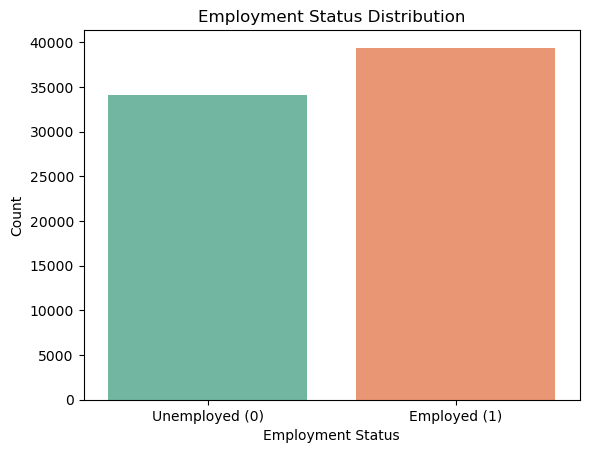

In [15]:
# Target Variable Distribution
import warnings
warnings.filterwarnings("ignore")
sns.countplot(data=df, x="Employed", palette="Set2")
plt.xticks(ticks=[0, 1], labels=["Unemployed (0)", "Employed (1)"])
plt.xlabel("Employment Status")
plt.ylabel("Count")
plt.title("Employment Status Distribution")
plt.show()

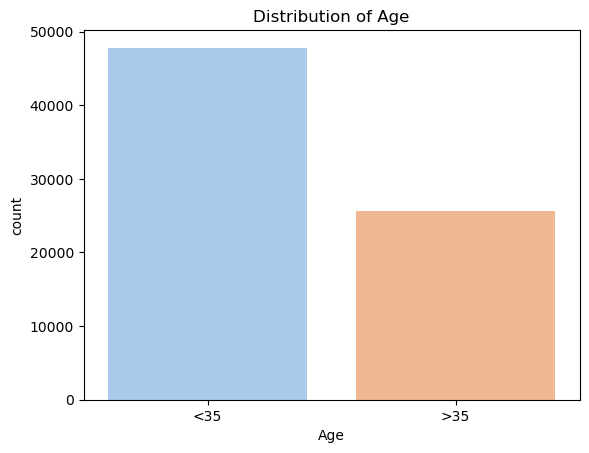

In [16]:
# Age Column Distribution

sns.countplot(data=df, x="Age", palette="pastel")
plt.title(f"Distribution of Age")
plt.xticks()
plt.show()

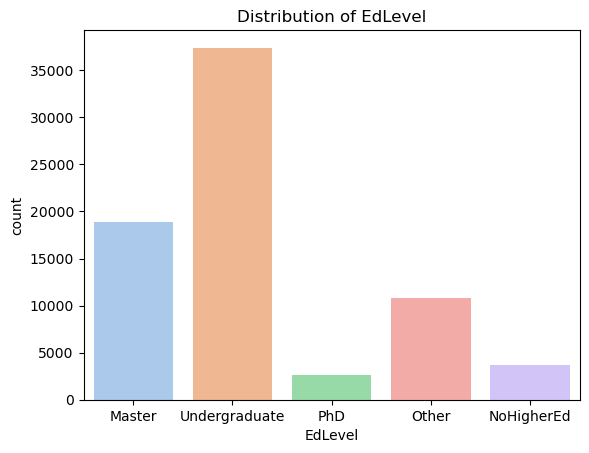

In [17]:
# Edlevel Column Distribution

sns.countplot(data=df, x="EdLevel", palette="pastel")
plt.title(f"Distribution of EdLevel")
plt.xticks()
plt.show()

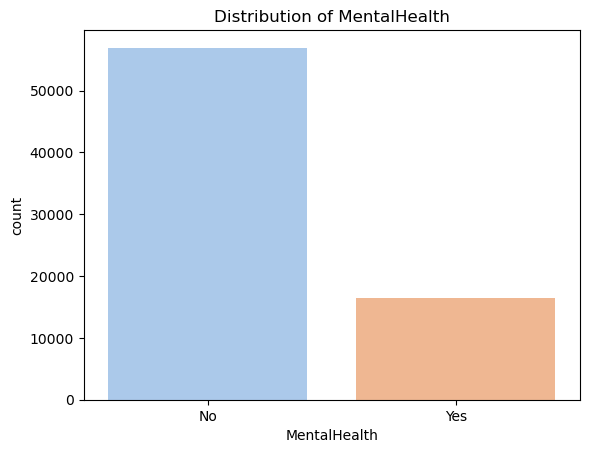

In [18]:
# MentalHealth Column Distribution

sns.countplot(data=df, x="MentalHealth", palette="pastel")
plt.title(f"Distribution of MentalHealth")
plt.xticks()
plt.show()

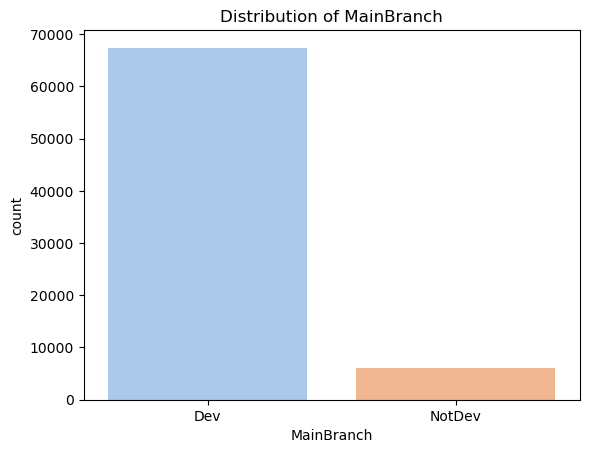

In [19]:
# MainBranch Column Distribution

sns.countplot(data=df, x="MainBranch", palette="pastel")
plt.title(f"Distribution of MainBranch")
plt.xticks()
plt.show()

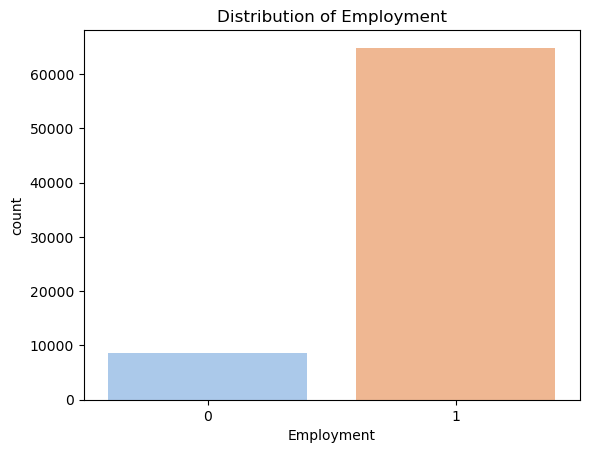

In [20]:
# Employment Column Distribution

sns.countplot(data=df, x="Employment", palette="pastel")
plt.title(f"Distribution of Employment")
plt.xticks()
plt.show()

### **2.Numerical Feature Distribution:**

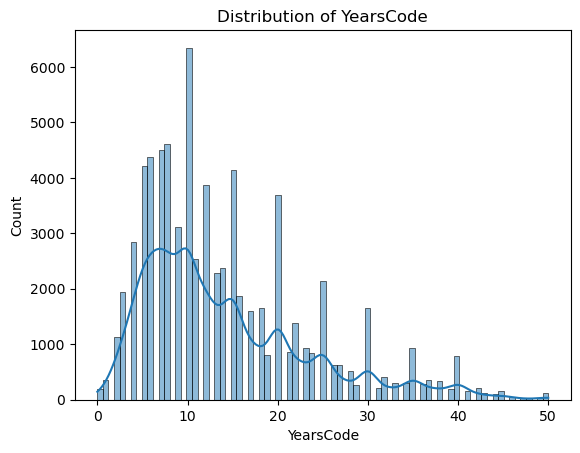

In [21]:
# YearsCode Column Distribution

sns.histplot(df["YearsCode"], kde=True)
plt.title(f"Distribution of YearsCode")
plt.show()

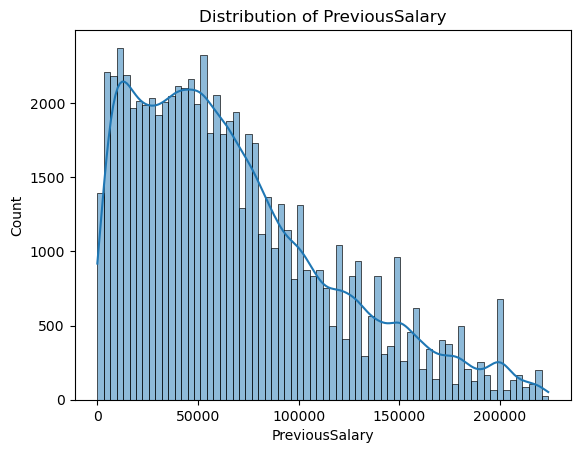

In [22]:
# PreviousSalary Column Distribution

sns.histplot(df["PreviousSalary"], kde=True)
plt.title(f"Distribution of PreviousSalary")
plt.show()

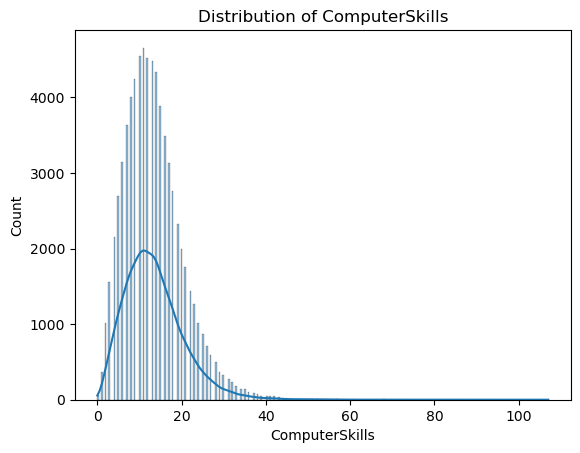

In [23]:
# ComputerSkills Column Distribution

sns.histplot(df["ComputerSkills"], kde=True)
plt.title(f"Distribution of ComputerSkills")
plt.show()

## **Multivariate Analysis:**

<Axes: >

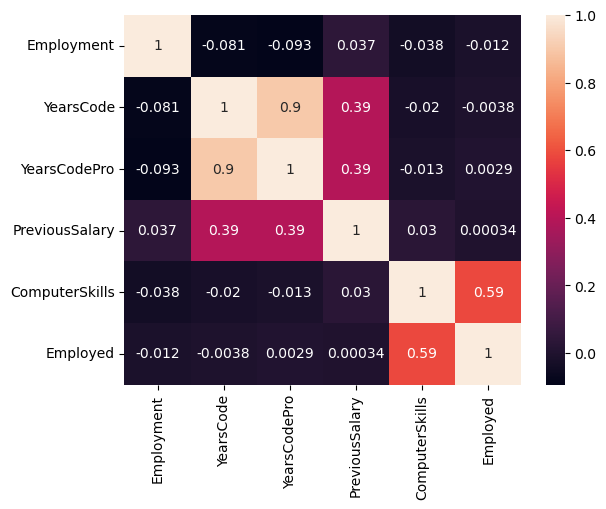

In [24]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

## **Feature Engineering:**

In [25]:
df["HaveWorkedWith"] = df["HaveWorkedWith"].str.split(";")
mlb = MultiLabelBinarizer()
df = df.join(pd.DataFrame(mlb.fit_transform(df.pop('HaveWorkedWith')),
                          columns=mlb.classes_,
                          index=df.index))

In [26]:
df.head()

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,PreviousSalary,...,Unity 3D,Unknown,Unreal Engine,VBA,VMware,Vue.js,Xamarin,Yarn,jQuery,npm
0,<35,No,Master,1,Man,No,Dev,7,4,51552.0,...,0,0,0,0,0,0,0,0,0,0
1,<35,No,Undergraduate,1,Man,No,Dev,12,5,46482.0,...,0,0,0,0,0,1,0,0,0,0
2,<35,No,Master,1,Man,No,Dev,15,6,77290.0,...,0,0,0,0,0,0,0,0,0,0
3,<35,No,Undergraduate,1,Man,No,Dev,9,6,46135.0,...,0,0,0,0,0,0,0,0,1,0
4,>35,No,PhD,0,Man,No,NotDev,40,30,160932.0,...,0,0,0,0,0,0,0,0,0,0


## **Selecting Target Variable and Predictors:**

In [27]:
y = df["Employed"]
X = df.drop(columns = "Employed")
print(y.shape)
print(X.shape)

(73458,)
(73458, 128)


## **Feature Selection:** 

In [28]:
cols = X.columns.tolist()
cat_cols = ["Age","Accessibility","EdLevel","Gender","MentalHealth","MainBranch"]
num_cols = ["YearsCode","YearsCodePro","PreviousSalary","ComputerSkills"]
for i in cat_cols:
    cols.remove(i)
for i in num_cols:
    cols.remove(i)
cat_cols.extend(num_cols)
cat_cols.extend(cols)

In [29]:
transformer = ColumnTransformer(transformers = [("Ordinal_Encoding",OrdinalEncoder(),[0,1,2,4,5,6]),
                                                ("MinMax_Scaler",MinMaxScaler(),[7,8,9,10])],remainder = "passthrough")
X_trans = transformer.fit_transform(X)
X_trans = pd.DataFrame(X_trans,columns = cat_cols)

In [30]:
# Mutual Information for Classification

mutual_info = mutual_info_classif(X_trans,y)
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_trans.columns
mutual_info.sort_values(ascending  = False)

ComputerSkills    0.248214
Node.js           0.137077
TypeScript        0.122772
JavaScript        0.099649
MongoDB           0.072653
                    ...   
Matlab            0.000000
Scala             0.000000
SAS               0.000000
Rust              0.000000
Pulumi            0.000000
Length: 128, dtype: float64

In [31]:
X = X.drop(columns = ["YearsCodePro","Accessibility","Gender"])

## **Splitting Data into Train and Test Data:**

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify = y,test_size = 0.2)

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(58766, 125)
(14692, 125)
(58766,)
(14692,)


## **Model Building:**

In [34]:
# Naive Bayes Algorithm

from sklearn.naive_bayes import GaussianNB

transformer = ColumnTransformer(transformers = [("Ordinal_encoding",OrdinalEncoder(),[0,1,3,4]),
                                                ("Standard_Scaling",StandardScaler(),[5,6,7])],
                                                    remainder = "passthrough")

nb_pipeline = Pipeline(steps = [("Transformer",transformer),
                                ("GaussianNB",GaussianNB())])
nb_pipeline.fit(X_train,y_train)
y_pred = nb_pipeline.predict(X_test)
# Let us Validate the Model
# Let us use accuracy_score
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
print(score)

0.7706915328069698


In [35]:
# KNN Classifier

from sklearn.neighbors import KNeighborsClassifier

transformer = ColumnTransformer(transformers = [("Ordinal_encoding",OrdinalEncoder(),[0,1,3,4]),
                                                ("Standard_Scaling",StandardScaler(),[5,6,7])],
                                                    remainder = "passthrough")

knn_pipeline = Pipeline(steps = [("Transformer",transformer),
                                ("KNNC",KNeighborsClassifier())])
knn_pipeline.fit(X_train,y_train)
y_pred = knn_pipeline.predict(X_test)
# Let us Validate the Model
# Let us use accuracy_score
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
print(score)

0.8682956711135311


In [36]:
from sklearn.tree import DecisionTreeClassifier

# Column transformer for preprocessing
transformer = ColumnTransformer(transformers=[
    ("Ordinal_encoding", OrdinalEncoder(), [0,1,3,4]),
    ("Standard_Scaling", StandardScaler(), [5,6,7])
], remainder="passthrough")

# Pipeline with Decision Tree
dtc_pipeline = Pipeline(steps=[
    ("Transformer", transformer),
    ("DTC", DecisionTreeClassifier(random_state=42))
])

# Hyperparameter grid for tuning Decision Tree inside pipeline
param_grid = {
    "DTC__max_depth": [i for i in range(1,20)]
    # "DTC__min_samples_split": [i for i in range(1,20)],
    # "DTC__min_samples_leaf": [i for i in range(1,20)],
}

# GridSearchCV
grid_search = GridSearchCV(estimator=dtc_pipeline,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=2,
                           scoring='accuracy')

# Fit the GridSearch on training data
grid_search.fit(X_train, y_train)

# Best parameters and CV score
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Predict on test data using best estimator
y_pred = grid_search.best_estimator_.predict(X_test)

# Evaluate accuracy on test set
test_score = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_score)

Fitting 5 folds for each of 19 candidates, totalling 95 fits
Best Parameters: {'DTC__max_depth': 12}
Best CV Accuracy: 0.9970050417112448
Test Accuracy: 0.9987067791995644


In [37]:
# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

transformer = ColumnTransformer(transformers = [("Ordinal_encoding",OrdinalEncoder(),[0,1,3,4]),
                                                ("Standard_Scaling",StandardScaler(),[5,6,7])],
                                                    remainder = "passthrough")

dtc_pipeline = Pipeline(steps = [("Transformer",transformer),
                                ("DTC",DecisionTreeClassifier(max_depth = 12))])
dtc_pipeline.fit(X_train,y_train)
y_pred = dtc_pipeline.predict(X_test)
# Let us Validate the Model
# Let us use accuracy_score
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
print(score)

0.9987067791995644


In [38]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

transformer = ColumnTransformer(transformers = [("Ordinal_encoding",OrdinalEncoder(),[0,1,3,4]),
                                                ("Standard_Scaling",StandardScaler(),[5,6,7])],
                                                    remainder = "passthrough")

rfc_pipeline = Pipeline(steps = [("Transformer",transformer),
                                ("RFC",RandomForestClassifier(max_depth = 10))])
rfc_pipeline.fit(X_train,y_train)
y_pred = rfc_pipeline.predict(X_test)
# Let us Validate the Model
# Let us use accuracy_score
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
print(score)

0.9364279880206915


In [39]:
with open("ep_pipeline.pkl","wb") as f:
    pickle.dump(dtc_pipeline,f)

In [40]:
with open("ep_pipeline.pkl","rb") as f:
    model = pickle.load(f)